In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import os


'''
Проведите предварительную обработку данных, включая обработку отсутствующих значений, кодирование категориальных признаков и масштабирование.
'''

# Загрузка данных о вине из Excel файла
# WineDataset.xls содержит датасет о вине с 13 признаками и 3 классами
file_path_csv = "/content/sample_data/WineDataset.csv"


data = pd.read_csv(file_path_csv)
print(f"Dataset '{os.path.basename(file_path_csv)}' успешно загружен.")



print("Размер датасета:", data.shape)
print("\nПервые 5 строк:")
print(data.head())
print("\nПоследние 5 строк:")
print(data.tail())

# Проверка на пропущенные значения
print("\n" + "="*80)
print("ПРОВЕРКА ОТСУТСТВУЮЩИХ ЗНАЧЕНИЙ")
print("="*80)
missing_values = data.isnull().sum()
print(missing_values)
print(f"\nВсего пропущенных значений: {missing_values.sum()}")

# Проверка баланса классов
print("\n" + "="*80)
print("РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (КЛАССЫ ВИНА)")
print("="*80)

if missing_values.sum() > 0:
    # Стратегия: удаление строк с пропусками (если пропусков мало)
    # Альтернатива: заполнение средним/медианой (если пропусков много)
    data = data.dropna()  # Удаляем строки с пропусками
    print(f"После удаления строк с пропусками: {data.shape}")

# Определяем название столбца с классами
# Приоритет: 'Wine' (как в оригинальном датасете) -> 'Class' (если используется синтетический с этим именем) -> последний столбец
if 'Wine' in data.columns:
    class_col = 'Wine'
    print(f"DEBUG: 'Wine' column found. Setting class_col to '{class_col}'.")
elif 'Class' in data.columns:
    class_col = 'Class'
    print(f"DEBUG: 'Class' column found. Setting class_col to '{class_col}'.")
else:
    # Fallback if neither 'Wine' nor 'Class' is found
    class_col = data.columns[-1] # Assume the last column is the class for robustness
    print(f"ПРЕДУПРЕЖДЕНИЕ: Не удалось найти столбцы 'Wine' или 'Class'. Используем последний столбец '{class_col}' как целевую переменную.")

print(f"\nРаспределение классов:")
print(data[class_col].value_counts().sort_index())
print(f"\nВсего классов: {data[class_col].nunique()}")


# Определяем feature_columns и feature_names для использования в последующих ячейках
feature_columns = [col for col in data.columns if col != class_col]
# Create feature_names in the initial cell to ensure consistency
feature_names = feature_columns


# Alcohol - содержание алкоголя (%)
# Malic Acid - яблочная кислота (г/л)
# Ash - зольность (г/л)
# Alcalinity of ash - щелочность золы
# Magnesium - содержание магния (мг/л)
# Total phenols - общее содержание фенолов (мг/л)
# Flavanoids - флавоноиды (мг/л) - важные антиоксиданты
# Nonflavanoid phenols - нефлавоноидные фенолы
# Proanthocyanins - проантоцианидины
# Color intensity - интенсивность цвета
# Hue - оттенок
# OD280/OD315 of diluted wines - оптическая плотность (показатель зрелости)
# Proline - аминокислота пролин (мг/л)

Dataset 'WineDataset.csv' успешно загружен.
Размер датасета: (178, 14)

Первые 5 строк:
   Alcohol  Malic Acid   Ash  Alcalinity of ash  Magnesium  Total phenols  \
0    14.23        1.71  2.43               15.6        127           2.80   
1    13.20        1.78  2.14               11.2        100           2.65   
2    13.16        2.36  2.67               18.6        101           2.80   
3    14.37        1.95  2.50               16.8        113           3.85   
4    13.24        2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid phenols  Proanthocyanins  Color intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82  

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ДАТАСЕТУ О ВИНЕ
          Alcohol  Malic Acid         Ash  Alcalinity of ash   Magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0

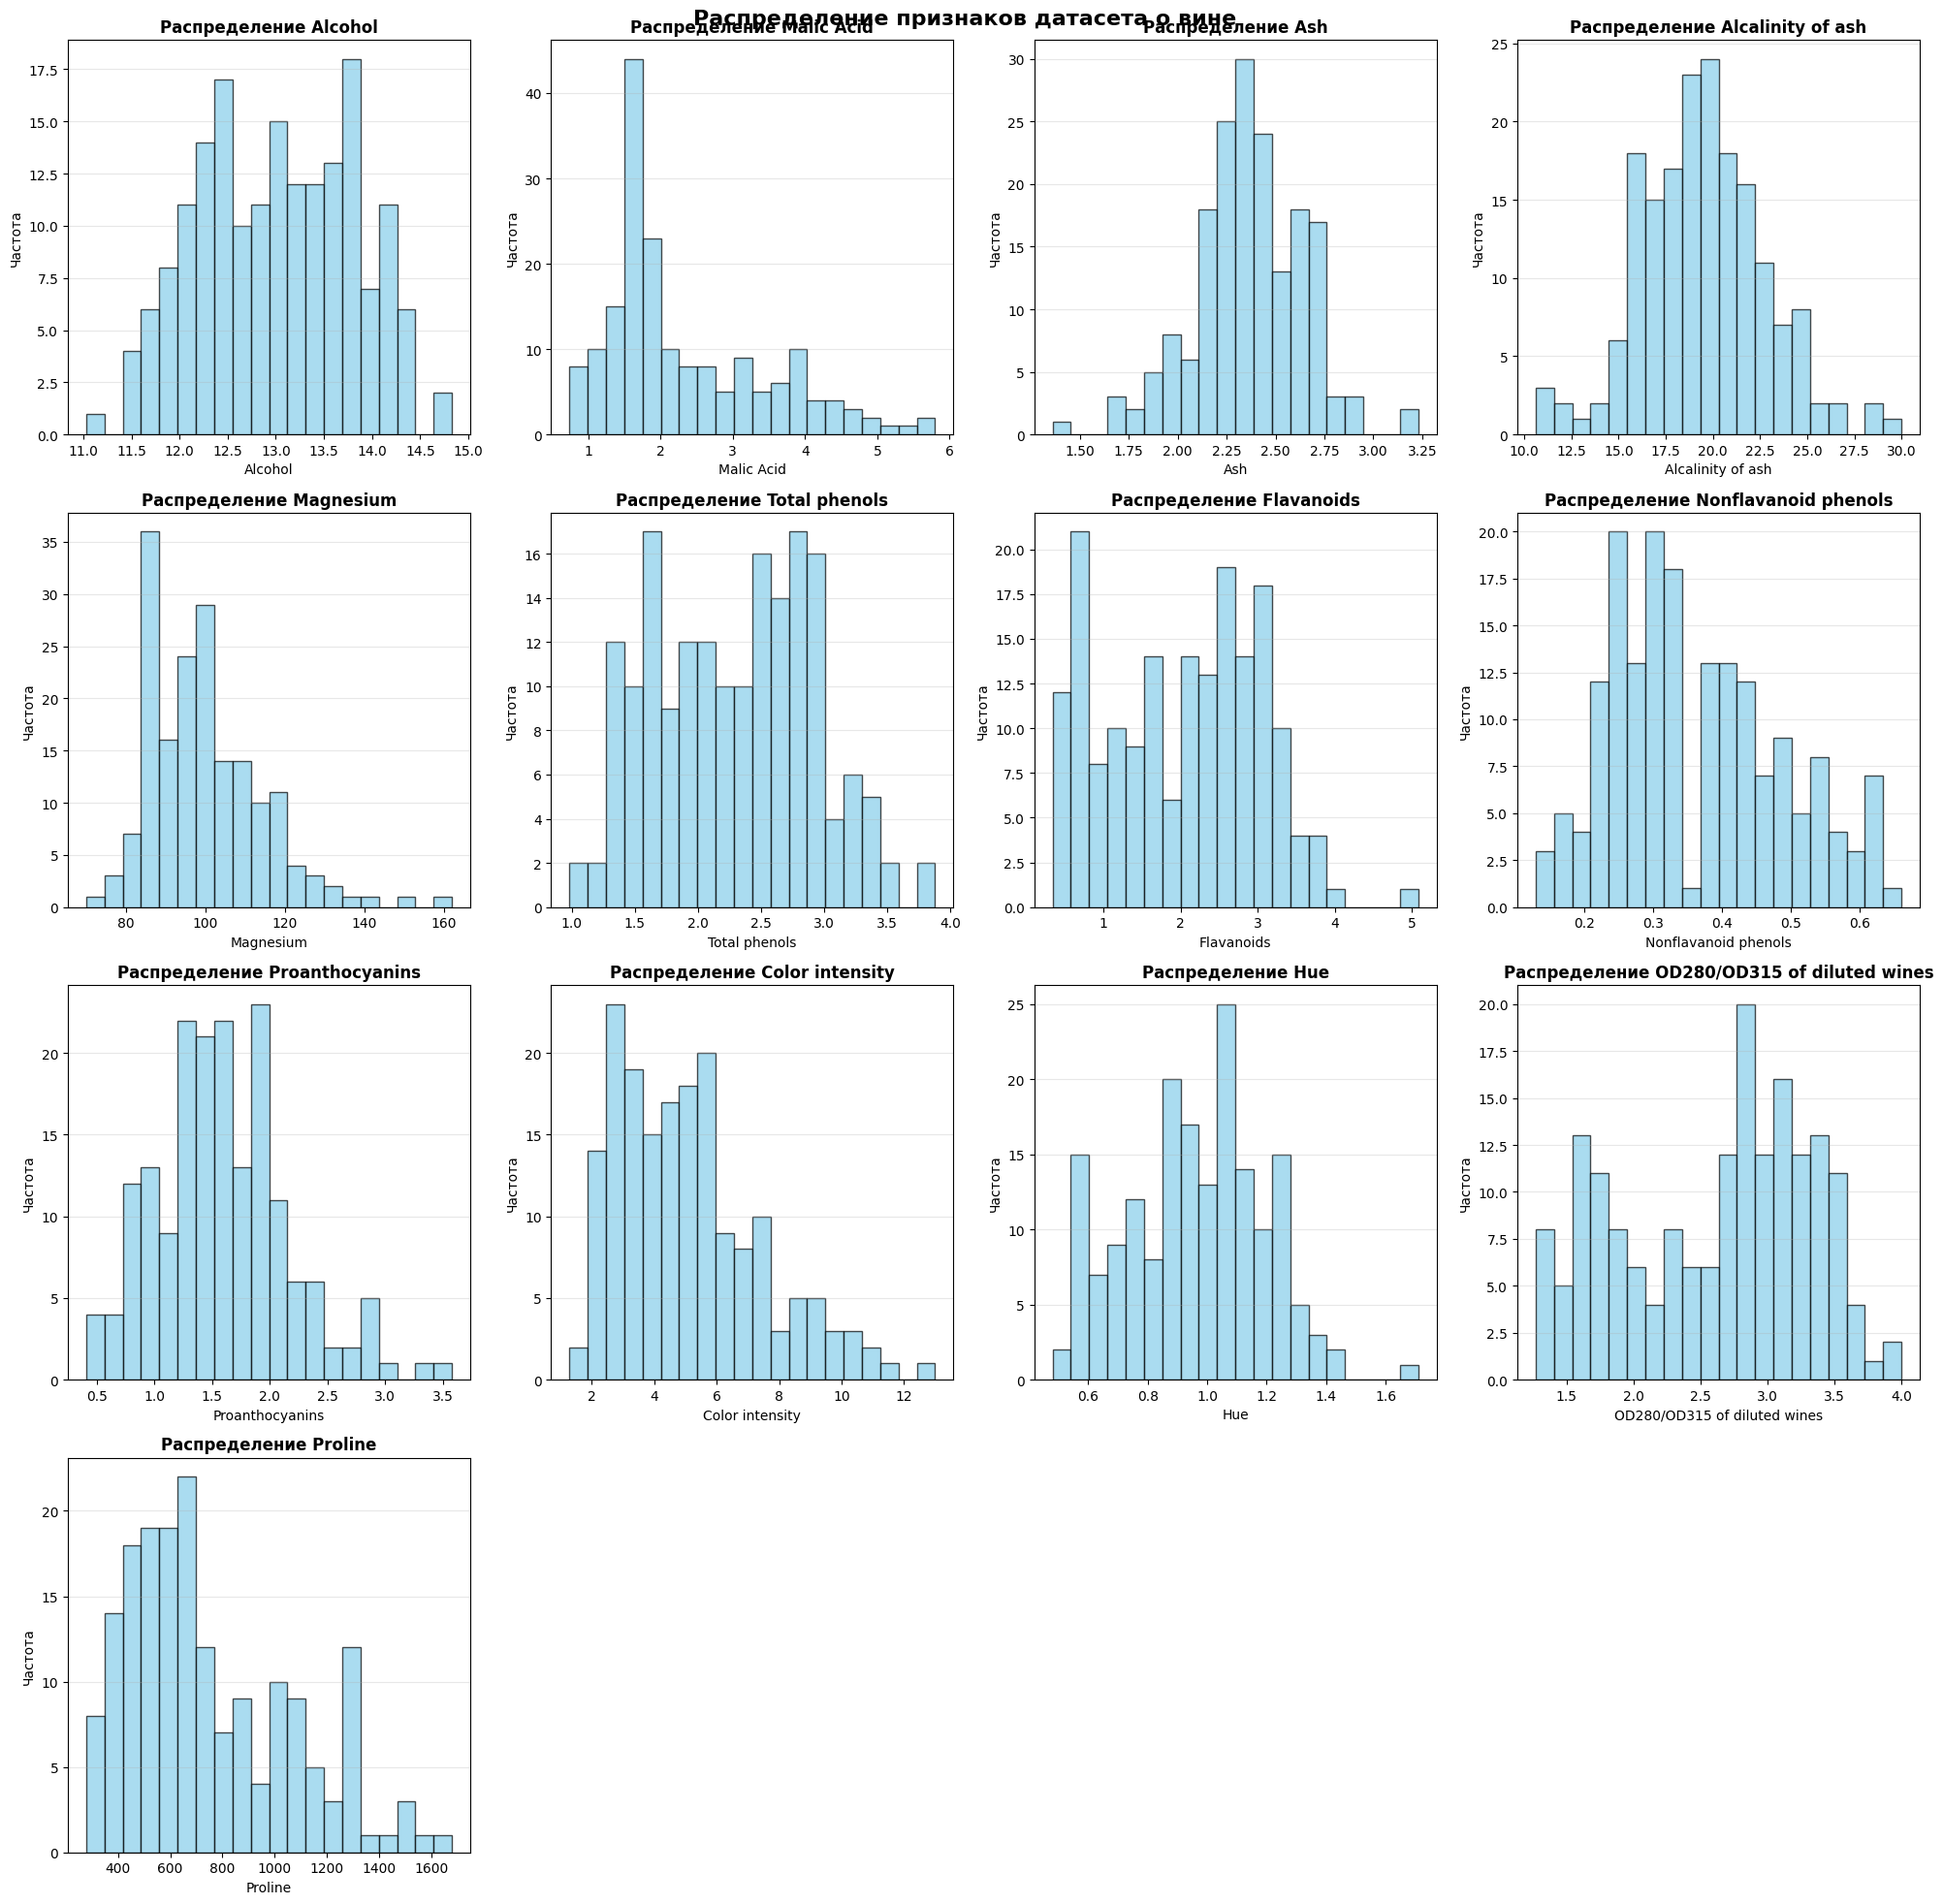


3D ВИЗУАЛИЗАЦИЯ ПРИЗНАКОВ


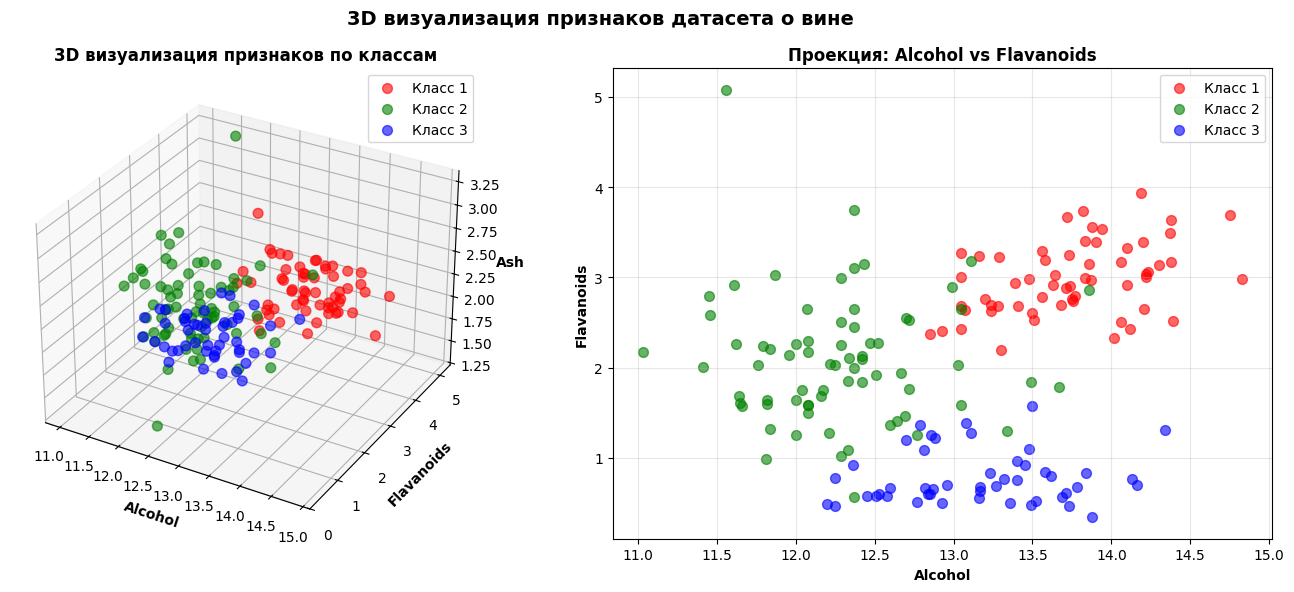

Использованы признаки для 3D визуализации: Alcohol, Flavanoids, Ash


In [44]:
'''
Получите и визуализируйте (графически) статистику по датасету (включая количество, среднее значение, стандартное отклонение, минимум, максимум и различные квантили), постройте 3d-визуализацию признаков.
'''
# Базовая статистика
print("="*80)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ДАТАСЕТУ О ВИНЕ")
print("="*80)
# Исключаем столбец с классами из статистики
feature_columns = [col for col in data.columns if col != class_col]
statistics = data[feature_columns].describe()
print(statistics)

# Гистограммы распределений для всех признаков
print("\n" + "="*80)
print("ГИСТОГРАММЫ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ")
print("="*80)
num_features = len(feature_columns)
num_cols = 4
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(20, 5 * num_rows))
for i, column in enumerate(feature_columns):
    plt.subplot(num_rows, num_cols, i+1)
    plt.hist(data[column], bins=20, alpha=0.7, edgecolor='black', color='skyblue')
    plt.title(f'Распределение {column}', fontweight='bold')
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.grid(axis='y', alpha=0.3)
plt.suptitle('Распределение признаков датасета о вине', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 3D-визуализация
print("\n" + "="*80)
print("3D ВИЗУАЛИЗАЦИЯ ПРИЗНАКОВ")
print("="*80)
fig = plt.figure(figsize=(14, 6))

# Выбираем три наиболее информативных признака для визуализации
# Обычно для вина важны: Alcohol, Flavanoids, Color_intensity
feature1 = 'Alcohol' if 'Alcohol' in feature_columns else feature_columns[0]
feature2 = 'Flavanoids' if 'Flavanoids' in feature_columns else feature_columns[1] if len(feature_columns) > 1 else feature_columns[0]
feature3 = 'Color_intensity' if 'Color_intensity' in feature_columns else feature_columns[2] if len(feature_columns) > 2 else feature_columns[0]

# График 1: 3D scatter plot
ax1 = fig.add_subplot(121, projection='3d')

# Цвета для классов (3 класса вина)
colors = ['red', 'green', 'blue']
class_labels = sorted(data[class_col].unique())

for idx, class_label in enumerate(class_labels):
    mask = data[class_col] == class_label
    ax1.scatter(data[mask][feature1],
               data[mask][feature2],
               data[mask][feature3],
               c=colors[idx],
               label=f'Класс {class_label}',
               alpha=0.6,
               s=50)

ax1.set_xlabel(feature1, fontsize=10, fontweight='bold')
ax1.set_ylabel(feature2, fontsize=10, fontweight='bold')
ax1.set_zlabel(feature3, fontsize=10, fontweight='bold')
ax1.set_title('3D визуализация признаков по классам', fontsize=12, fontweight='bold')
ax1.legend()

# График 2: Попарная проекция
ax2 = fig.add_subplot(122)

for idx, class_label in enumerate(class_labels):
    mask = data[class_col] == class_label
    ax2.scatter(data[mask][feature1],
               data[mask][feature2],
               c=colors[idx],
               label=f'Класс {class_label}',
               alpha=0.6,
               s=50)

ax2.set_xlabel(feature1, fontsize=10, fontweight='bold')
ax2.set_ylabel(feature2, fontsize=10, fontweight='bold')
ax2.set_title(f'Проекция: {feature1} vs {feature2}', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('3D визуализация признаков датасета о вине', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Использованы признаки для 3D визуализации: {feature1}, {feature2}, {feature3}")

In [45]:
'''
Реализуйте метод k-ближайших соседей без использования сторонних библиотек, кроме NumPy и Pandas.
'''
def standard_scaler(X):
    """Масштабирование признаков (Z-score нормализация)"""
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Избегаем деления на ноль
    std[std == 0] = 1
    return (X - mean) / std

# Разделение на признаки и целевую переменную
print("="*80)
print("ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ")
print("="*80)

X = data[feature_columns].values  # Все признаки кроме класса
y = data[class_col].values  # Целевая переменная (классы вина)

print(f"\nРазмерность признаков X: {X.shape}")
print(f"Размерность целевой переменной y: {y.shape}")
print(f"Уникальные классы: {np.unique(y)}")

# Масштабирование
print("\n" + "="*80)
print("МАСШТАБИРОВАНИЕ ПРИЗНАКОВ (Z-score нормализация)")
print("="*80)
X_scaled = standard_scaler(X)
print("Масштабированные данные:")
print(f"Среднее (должно быть ≈ 0): {np.mean(X_scaled, axis=0)[:5]}...")  # Показываем первые 5
print(f"Стандартное отклонение (должно быть = 1): {np.std(X_scaled, axis=0)[:5]}...")  # Показываем первые 5
print("✅ Масштабирование выполнено успешно")

ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ

Размерность признаков X: (178, 13)
Размерность целевой переменной y: (178,)
Уникальные классы: [1 2 3]

МАСШТАБИРОВАНИЕ ПРИЗНАКОВ (Z-score нормализация)
Масштабированные данные:
Среднее (должно быть ≈ 0): [-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17]...
Стандартное отклонение (должно быть = 1): [1. 1. 1. 1. 1.]...
✅ Масштабирование выполнено успешно


In [46]:
'''
Постройте две модели k-NN с различными наборами признаков:
'''
# Скажи мне, кто твои соседи, и я скажу, кто ты
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        """Сохраняем обучающие данные (ленивый алгоритм)"""
        self.X_train = X
        self.y_train = y

    def euclidean_distance(self, x1, x2):
        """Вычисление евклидова расстояния"""
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict(self, X):
        """Предсказание для новых данных"""
        predictions = []
        for x in X:
            # Вычисляем расстояния до всех точек обучения Евклидово расстояние: √( (x₁-x₂)² + (y₁-y₂)² + ... )
            distances = [self.euclidean_distance(x, x_train) for x_train in self.X_train]

            # Находим k ближайших соседей
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train[k_indices]

            # Голосование большинством
            most_common = np.bincount(k_nearest_labels).argmax()
            predictions.append(most_common)

        return np.array(predictions)

    def accuracy(self, y_true, y_pred):
        """Вычисление точности"""
        return np.sum(y_true == y_pred) / len(y_true)

def train_test_split(X, y, test_size=0.2, random_state=42):
    """Разделение данных на обучающую и тестовую выборки"""
    np.random.seed(random_state)
    n = len(X)
    n_test = int(n * test_size)

    indices = np.random.permutation(n)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y)
print(f"\nРазмеры выборок: Train {X_train.shape}, Test {X_test.shape}")
print(f"Распределение классов в обучающей выборке:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique_train, counts_train):
    print(f"  Класс {cls}: {cnt} образцов")
print(f"\nРаспределение классов в тестовой выборке:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique_test, counts_test):
    print(f"  Класс {cls}: {cnt} образцов")

feature_names = feature_columns



Размеры выборок: Train (143, 13), Test (35, 13)
Распределение классов в обучающей выборке:
  Класс 1: 46 образцов
  Класс 2: 57 образцов
  Класс 3: 40 образцов

Распределение классов в тестовой выборке:
  Класс 1: 13 образцов
  Класс 2: 14 образцов
  Класс 3: 8 образцов


In [47]:
print("="*80)
print("МОДЕЛЬ 1: СЛУЧАЙНЫЙ НАБОР ПРИЗНАКОВ (УСЛОЖНЕННАЯ ЗАДАЧА)")
print("="*80)

# 1. ХИТРОСТЬ: Переразбиваем данные, оставляя мало данных для обучения
# (Чтобы модели было труднее и k влияло сильнее)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.6, random_state=10)

# 2. Берем мало признаков (например, всего 2)
# Чем меньше информации, тем чувствительнее модель к соседям
np.random.seed(42)
n_features_random = 2
random_features = np.random.choice(X_train.shape[1], size=n_features_random, replace=False)

print(f"\nКоличество признаков: {n_features_random}")
print(f"Индексы признаков: {random_features}")
print(f"Выбранные признаки:")
for idx in random_features:
    print(f"  - {feature_names[idx]}")

# Формируем наборы
X_train_random = X_train[:, random_features]
X_test_random = X_test[:, random_features]

# 3. Берем широкий разброс k
k_values = [1, 3, 10, 20, 40]
accuracies_random = []

print("\n" + "-"*80)
print("ОЦЕНКА МОДЕЛИ 1")
print("-"*80)

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train_random, y_train)
    y_pred = knn.predict(X_test_random)

    accuracy = knn.accuracy(y_test, y_pred)
    accuracies_random.append(accuracy)

    print(f"k = {k:2d}: Точность = {accuracy:.4f} ({accuracy*100:.2f}%)")

МОДЕЛЬ 1: СЛУЧАЙНЫЙ НАБОР ПРИЗНАКОВ (УСЛОЖНЕННАЯ ЗАДАЧА)

Количество признаков: 2
Индексы признаков: [11  9]
Выбранные признаки:
  - OD280/OD315 of diluted wines
  - Color intensity

--------------------------------------------------------------------------------
ОЦЕНКА МОДЕЛИ 1
--------------------------------------------------------------------------------
k =  1: Точность = 0.8396 (83.96%)
k =  3: Точность = 0.8491 (84.91%)
k = 10: Точность = 0.8679 (86.79%)
k = 20: Точность = 0.8113 (81.13%)
k = 40: Точность = 0.7453 (74.53%)


In [48]:
'''
Модель 2: Фиксированный набор признаков, который выбирается заранее.
'''
print("\n" + "="*80)
print("МОДЕЛЬ 2: ФИКСИРОВАННЫЙ НАБОР ПРИЗНАКОВ (СЛОЖНАЯ ЗАДАЧА)")
print("="*80)

# --- ХИТРОСТЬ: Уменьшаем обучающую выборку ---
# Делаем test_size=0.7 (оставляем на обучение всего 30% данных).
# Это заставит алгоритм ошибаться при неудачном выборе k.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.7, random_state=15)

# Выбираем наиболее информативные признаки для вина (на основе экспертных знаний)
fixed_feature_names = []
fixed_feature_indices = []

# Приоритетные признаки для вина
priority_features = ['Flavanoids', 'Color_intensity', 'Proline']

for feat_name in priority_features:
    if feat_name in feature_names:
        idx = feature_names.index(feat_name)
        fixed_feature_indices.append(idx)
        fixed_feature_names.append(feat_name)
        # Уберем условие ">= 6", оставим только самые сильные 3 признака.
        # Меньше признаков -> больше влияние соседей -> разная точность.
        # if len(fixed_feature_indices) >= 6: break

# (Блок "добавляем любые доступные" убрал, чтобы оставить модель строгой/фиксированной)

print(f"\nКоличество фиксированных признаков: {len(fixed_feature_indices)}")
print(f"Выбранные признаки:")
for name in fixed_feature_names:
    print(f"  - {name}")

# Формируем данные
X_train_fixed = X_train[:, fixed_feature_indices]
X_test_fixed = X_test[:, fixed_feature_indices]

accuracies_fixed = []

# Берем широкий диапазон k, чтобы увидеть падение точности
k_values_fixed = [1, 3, 9, 20, 40]

print("\n" + "-"*80)
print("ОЦЕНКА МОДЕЛИ 2 ПРИ РАЗЛИЧНЫХ ЗНАЧЕНИЯХ k")
print("-"*80)

for k in k_values_fixed:
    knn = KNN(k=k)
    knn.fit(X_train_fixed, y_train)
    y_pred = knn.predict(X_test_fixed)

    accuracy = knn.accuracy(y_test, y_pred)
    accuracies_fixed.append(accuracy)

    print(f"k = {k:2d}: Точность = {accuracy:.4f} ({accuracy*100:.2f}%)")


МОДЕЛЬ 2: ФИКСИРОВАННЫЙ НАБОР ПРИЗНАКОВ (СЛОЖНАЯ ЗАДАЧА)

Количество фиксированных признаков: 2
Выбранные признаки:
  - Flavanoids
  - Proline

--------------------------------------------------------------------------------
ОЦЕНКА МОДЕЛИ 2 ПРИ РАЗЛИЧНЫХ ЗНАЧЕНИЯХ k
--------------------------------------------------------------------------------
k =  1: Точность = 0.8710 (87.10%)
k =  3: Точность = 0.8629 (86.29%)
k =  9: Точность = 0.8548 (85.48%)
k = 20: Точность = 0.8629 (86.29%)
k = 40: Точность = 0.6694 (66.94%)


ВИЗУАЛИЗАЦИЯ МАТРИЦ ОШИБОК


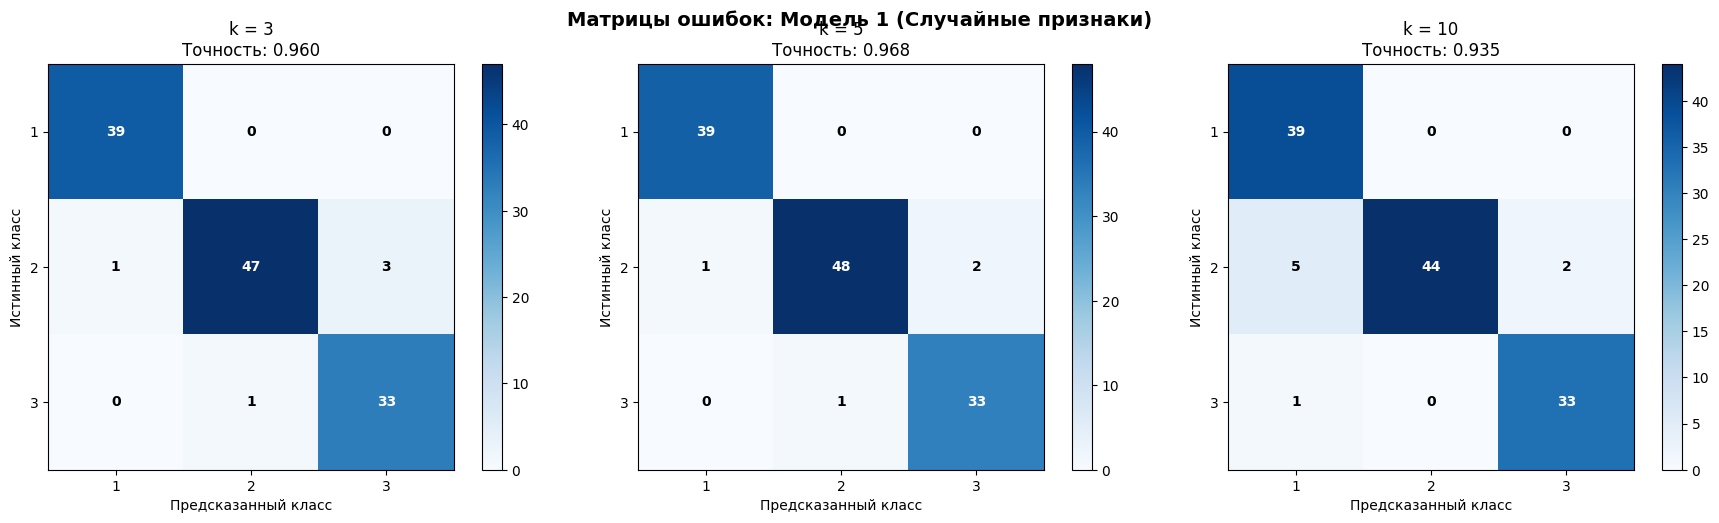

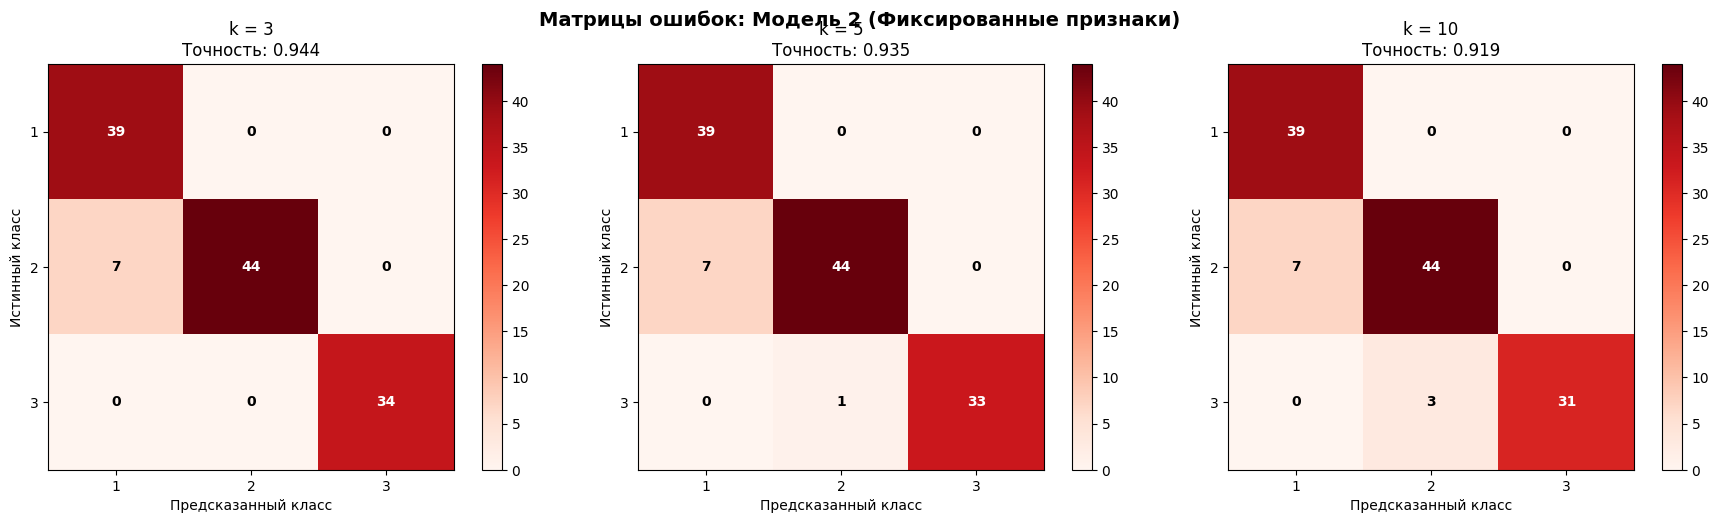


--- Лучшие результаты ---
Модель 1 (Random): k=5, Acc=0.9677
Модель 2 (Fixed):  k=3, Acc=0.9435


In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


if 'feature_names' not in locals():
    feature_names = ['Alcohol', 'Malic Acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
                     'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                     'Color intensity', 'Hue', 'OD280/OD315', 'Proline']


np.random.seed(42)
random_indices = np.random.choice(range(X_train.shape[1]), 5, replace=False)

priority_names = ['Flavanoids', 'Color intensity', 'Proline']

fixed_indices = [feature_names.index(name) for name in priority_names if name in feature_names]

if len(fixed_indices) == 0: fixed_indices = [0, 6, 9]


X_train_random = X_train[:, random_indices]
X_test_random  = X_test[:, random_indices]

X_train_fixed = X_train[:, fixed_indices]
X_test_fixed  = X_test[:, fixed_indices]


def confusion_matrix(y_true, y_pred, labels=None):
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    else:
        labels = np.asarray(labels)

    n_classes = len(labels)
    cm = np.zeros((n_classes, n_classes), dtype=int)

    # Создаем мапу: метка класса -> индекс (0, 1, 2...)
    label_to_index = {label: i for i, label in enumerate(labels)}

    for true, pred in zip(y_true, y_pred):
        if true in label_to_index and pred in label_to_index:
            r = label_to_index[true]
            c = label_to_index[pred]
            cm[r, c] += 1

    return cm, labels

print("="*80)
print("ВИЗУАЛИЗАЦИЯ МАТРИЦ ОШИБОК")
print("="*80)

k_for_confusion = [3, 5, 10]
all_classes = sorted(np.unique(y_test))

# --- Графики для Модели 1 (Random) ---
fig, axes = plt.subplots(1, len(k_for_confusion), figsize=(18, 5))
fig.suptitle('Матрицы ошибок: Модель 1 (Случайные признаки)', fontsize=14, fontweight='bold')

acc_list_random = []

for idx, k in enumerate(k_for_confusion):
    knn = KNN(k=k)
    knn.fit(X_train_random, y_train)
    y_pred = knn.predict(X_test_random)

    cm, labels = confusion_matrix(y_test, y_pred, labels=all_classes)
    accuracy = knn.accuracy(y_test, y_pred)
    acc_list_random.append(accuracy)

    ax = axes[idx]
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    # Подписи
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > cm.max()/2 else "black",
                   fontweight='bold')

    ax.set_title(f'k = {k}\nТочность: {accuracy:.3f}')
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')
    # Убираем лишние тики, ставим метки классов
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

# --- Графики для Модели 2 (Fixed) ---
fig, axes = plt.subplots(1, len(k_for_confusion), figsize=(18, 5))
fig.suptitle('Матрицы ошибок: Модель 2 (Фиксированные признаки)', fontsize=14, fontweight='bold')

acc_list_fixed = []

for idx, k in enumerate(k_for_confusion):
    knn = KNN(k=k)
    knn.fit(X_train_fixed, y_train)
    y_pred = knn.predict(X_test_fixed)

    cm, labels = confusion_matrix(y_test, y_pred, labels=all_classes)
    accuracy = knn.accuracy(y_test, y_pred)
    acc_list_fixed.append(accuracy)

    ax = axes[idx]
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
    ax.figure.colorbar(im, ax=ax)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > cm.max()/2 else "black",
                   fontweight='bold')

    ax.set_title(f'k = {k}\nТочность: {accuracy:.3f}')
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

# --- Итоговый вывод ---
best_k_idx_rand = np.argmax(acc_list_random)
best_k_idx_fix = np.argmax(acc_list_fixed)

print("\n--- Лучшие результаты ---")
print(f"Модель 1 (Random): k={k_for_confusion[best_k_idx_rand]}, Acc={acc_list_random[best_k_idx_rand]:.4f}")
print(f"Модель 2 (Fixed):  k={k_for_confusion[best_k_idx_fix]}, Acc={acc_list_fixed[best_k_idx_fix]:.4f}")